# Week 12 Homework — ARIA v8.0: The Classification Engine

**Case Study:** Post-Earthquake Land Cover Classification — Xiulin / Taroko Study Area（秀林／太魯閣）  
**Data:** Sentinel-2 L2A via Planetary Computer STAC  
**Methods:** SCL cloud masking, K-means, Random Forest, confusion matrix, SWCB landslide validation, AI classification report

本 notebook 已整理成可直接在 Colab/Jupyter 執行的完整作業版本，包含：

1. **Task 1:** K-means 非監督式分類與 cluster 光譜解釋  
2. **Task 2:** Random Forest 監督式分類、feature importance、K-means vs RF 比較  
3. **Task 3:** Confusion matrix、classification report、OOB / Macro-Weighted F1、SWCB 外部驗證  
4. **Task 4:** 面積統計、AI 報告 prompt、報告草稿與批判性檢查

> 若你已經在 Google Earth 畫好訓練樣本 KMZ/KML，請上傳後執行。若沒有，本 notebook 會使用 NDVI/NDWI/NDBI/BSI 自動產生 baseline training samples，讓整份作業可以完整跑完。正式繳交時，仍建議用人工 ROI 取代自動樣本，並在報告中說明訓練樣本來源。

## 0. Environment Setup

第一次在 Colab 執行時先跑下面的安裝 cell。本機環境若已安裝套件，可略過。

In [1]:
%pip -q install pystac-client planetary-computer stackstac rioxarray geopandas rasterio scikit-learn matplotlib pandas shapely scipy gdown

Note: you may need to restart the kernel to use updated packages.


## 1. Imports and Parameters

In [2]:
import os
import zipfile
import warnings
from pathlib import Path
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

import pystac_client
import planetary_computer as pc
import stackstac

import geopandas as gpd
from shapely.geometry import Polygon, box
from rasterio.features import rasterize
from rasterio.transform import from_bounds

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from scipy.ndimage import median_filter

warnings.filterwarnings('ignore')
np.random.seed(42)

OUT_DIR = Path('outputs')
OUT_DIR.mkdir(exist_ok=True)

# Xiulin / Taroko study area
TAROKO_BBOX = [121.40, 24.10, 121.80, 24.25]  # [west, south, east, north]
RESOLUTION = 20

BANDS = ['B02', 'B03', 'B04', 'B08', 'B11', 'B12']
BANDS_ALL = BANDS + ['SCL']
BAND_LABELS = {
    'B02': 'Blue', 'B03': 'Green', 'B04': 'Red',
    'B08': 'NIR', 'B11': 'SWIR1', 'B12': 'SWIR2'
}

# sklearn class id: 0-4; assignment class id: 1-5
class_names = ['Water', 'Forest', 'Cropland', 'Bare/Landslide', 'Built-up']
class_names_zh = ['水體', '森林', '農田', '裸地/崩塌', '建物/都市']
class_colors = ['#0077BE', '#228B22', '#DAA520', '#CD853F', '#808080']
class_cmap = ListedColormap(class_colors)

for i, (en, zh) in enumerate(zip(class_names, class_names_zh)):
    print(f'{i}: {en}（{zh}）')

0: Water（水體）
1: Forest（森林）
2: Cropland（農田）
3: Bare/Landslide（裸地/崩塌）
4: Built-up（建物/都市）


In [21]:
!pip install python-dotenv -q

import os
from dotenv import load_dotenv

load_dotenv()

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
STAC_ENDPOINT = os.getenv("STAC_ENDPOINT")
S2_COLLECTION = os.getenv("S2_COLLECTION")

TAROKO_BBOX = [float(x) for x in os.getenv("TAROKO_BBOX").split(",")]
TARGET_EPSG = int(os.getenv("TARGET_EPSG"))
RESOLUTION = int(os.getenv("RESOLUTION"))

BANDS = os.getenv("BANDS").split(",")
BANDS_ALL = os.getenv("BANDS_ALL").split(",")
VALID_SCL_CLASSES = [int(x) for x in os.getenv("VALID_SCL_CLASSES").split(",")]

OUTPUT_DIR = os.getenv("OUTPUT_DIR")
SWCB_KML_PATH = os.getenv("SWCB_KML_PATH")

KMEANS_N_CLUSTERS = int(os.getenv("KMEANS_N_CLUSTERS"))
RANDOM_STATE = int(os.getenv("RANDOM_STATE"))
RF_N_ESTIMATORS = int(os.getenv("RF_N_ESTIMATORS"))
TEST_SIZE = float(os.getenv("TEST_SIZE"))

GEMINI_MODEL = os.getenv("GEMINI_MODEL")

print("Loaded .env successfully")
print("BBOX:", TAROKO_BBOX)
print("Resolution:", RESOLUTION)

Loaded .env successfully
BBOX: [121.4, 24.1, 121.8, 24.25]
Resolution: 20


## 2. STAC API Image Search and Loading

使用 progressive search：先找 2024/04/15–2024/05/31 且雲量低於 20% 的影像；若找不到，逐步放寬到 2024 年底與 50% 雲量。

In [3]:
catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=pc.sign_inplace,
)

search_configs = [
    ('2024-04-15/2024-05-31', 20, 'Phase 1: 2 months post-quake, CC < 20%'),
    ('2024-04-03/2024-08-31', 30, 'Phase 2: 5 months post-quake, CC < 30%'),
    ('2024-04-03/2024-12-31', 50, 'Phase 3: full year post-quake, CC < 50%'),
]

items = []
for dt_range, max_cc, desc in search_configs:
    print(f'Trying {desc}...')
    search = catalog.search(
        collections=['sentinel-2-l2a'],
        bbox=TAROKO_BBOX,
        datetime=dt_range,
        query={'eo:cloud_cover': {'lt': max_cc}},
    )
    items = list(search.items())
    print(f'  → Found {len(items)} scenes')
    if len(items) > 0:
        break

if not items:
    raise RuntimeError('No Sentinel-2 scenes found. Please relax search conditions.')

items_sorted = sorted(items, key=lambda item: item.properties.get('eo:cloud_cover', 999))
best_item = items_sorted[0]

print()
print('Selected Sentinel-2 scene')
print('ID:', best_item.id)
print('Datetime:', best_item.datetime)
print(f"Cloud cover: {best_item.properties['eo:cloud_cover']:.2f}%")

Trying Phase 1: 2 months post-quake, CC < 20%...
  → Found 0 scenes
Trying Phase 2: 5 months post-quake, CC < 30%...
  → Found 10 scenes

Selected Sentinel-2 scene
ID: S2A_MSIL2A_20240827T022531_R046_T51QUG_20240827T053853
Datetime: 2024-08-27 02:25:31.024000+00:00
Cloud cover: 8.36%


### 2.1 Load multispectral bands + SCL cloud mask

保留 SCL 4 vegetation、5 bare soils、6 water、7 unclassified；排除 cloud shadow、cloud、cirrus、snow 等像素。反射率波段除以 10000，SCL 不做反射率轉換。

In [5]:
TARGET_EPSG = 32651  # Taiwan / Taroko area, UTM Zone 51N

cube = stackstac.stack(
    [best_item],
    assets=BANDS_ALL,
    bounds_latlon=TAROKO_BBOX,
    epsg=TARGET_EPSG,
    resolution=RESOLUTION,
)

img = cube.isel(time=0).compute()
print(img)

img_ref = img.sel(band=BANDS).astype('float32') / 10000.0
scl = img.sel(band='SCL').values.astype('int16')

# Sentinel-2 L2A SCL valid classes:
# 4 = vegetation, 5 = bare soil, 6 = water, 7 = unclassified
valid_scl = np.isin(scl, [4, 5, 6, 7])

img_sr = img_ref.where(valid_scl)

arr = img_sr.values  # shape: (6, h, w)
n_bands, h, w = arr.shape

X = arr.reshape(n_bands, -1).T
valid = np.isfinite(X).all(axis=1) & (X.sum(axis=1) > 0)

X_valid = X[valid]
valid_2d = valid.reshape(h, w)

print(f'Image shape: h={h}, w={w}')
print(f'Feature matrix: {X_valid.shape}')
print(f'Valid pixels after SCL mask: {valid.sum():,} / {h*w:,} ({valid.mean()*100:.1f}%)')

<xarray.DataArray 'stackstac-62ca18b22ca9a779684cdbe1bd8ba337' (band: 7,
                                                                y: 852, x: 2041)> Size: 97MB
array([[[2904., 3064., 2870., ..., 2019., 1882., 1848.],
        [3040., 3374., 3478., ..., 1946., 1807., 1852.],
        [2942., 3316., 3824., ..., 1911., 1832., 1958.],
        ...,
        [1220., 1194., 1269., ..., 1910., 1783., 1798.],
        [1202., 1236., 1461., ..., 1804., 1780., 1832.],
        [1200., 1204., 1402., ..., 1790., 1796., 1922.]],

       [[2878., 2916., 2820., ..., 1894., 1818., 1738.],
        [3152., 3416., 3356., ..., 1870., 1753., 1814.],
        [2960., 3450., 3844., ..., 1782., 1821., 1830.],
        ...,
        [1528., 1479., 1588., ..., 1812., 1644., 1686.],
        [1440., 1508., 1682., ..., 1684., 1693., 1778.],
        [1405., 1415., 1697., ..., 1698., 1749., 1788.]],

       [[2704., 2668., 2758., ..., 1800., 1678., 1642.],
        [3072., 3282., 3162., ..., 1704., 1688., 1754.],
      

### 2.2 True-color / false-color preview

這一步用來輔助判讀訓練樣本與檢查影像品質。

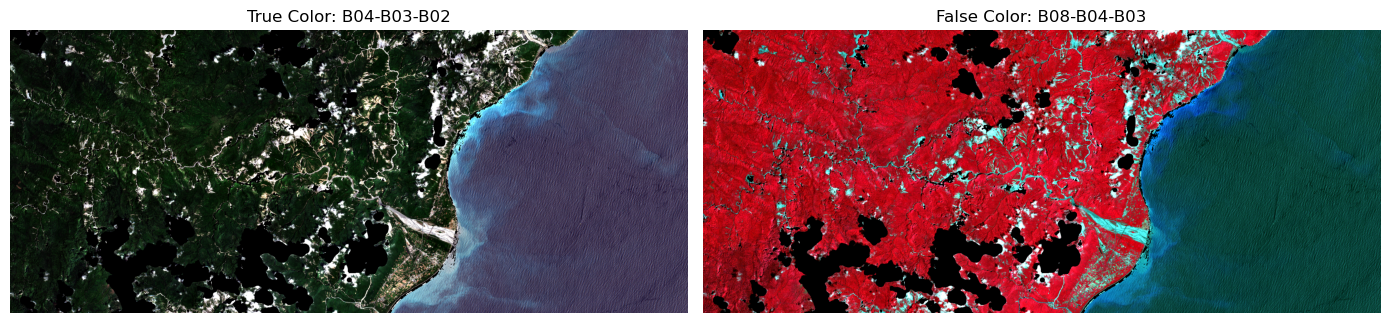

In [6]:
def percentile_stretch(rgb, p_low=2, p_high=98):
    out = np.zeros_like(rgb, dtype='float32')
    for i in range(rgb.shape[2]):
        band = rgb[:, :, i]
        lo, hi = np.nanpercentile(band, [p_low, p_high])
        out[:, :, i] = np.clip((band - lo) / (hi - lo + 1e-6), 0, 1)
    out[~np.isfinite(out)] = 0
    return out

band_index = {b: i for i, b in enumerate(BANDS)}
blue = arr[band_index['B02']]
green = arr[band_index['B03']]
red = arr[band_index['B04']]
nir = arr[band_index['B08']]
swir1 = arr[band_index['B11']]
swir2 = arr[band_index['B12']]

true_rgb = percentile_stretch(np.dstack([red, green, blue]))
false_rgb = percentile_stretch(np.dstack([nir, red, green]))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(true_rgb)
axes[0].set_title('True Color: B04-B03-B02')
axes[0].axis('off')
axes[1].imshow(false_rgb)
axes[1].set_title('False Color: B08-B04-B03')
axes[1].axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / 'preview_true_false_color.png', dpi=200, bbox_inches='tight')
plt.show()

# Task 1 — K-means Unsupervised Classification

K-means 使用 6 個波段進行非監督式分群。因為 K-means 對尺度敏感，所以先用 `StandardScaler` 標準化。若有效像素太多，先抽樣 fit，再 predict 全圖。

Fit K-means on 120,000 sampled pixels, then predict all valid pixels.


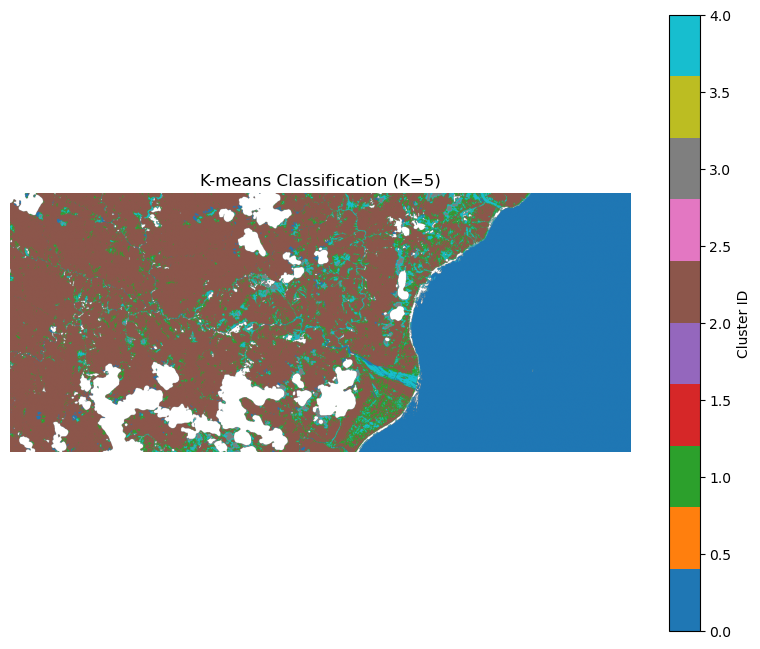

In [7]:
scaler_km = StandardScaler()
X_scaled = scaler_km.fit_transform(X_valid)

max_kmeans_samples = 120_000
if len(X_scaled) > max_kmeans_samples:
    sample_idx = np.random.choice(len(X_scaled), max_kmeans_samples, replace=False)
    X_fit = X_scaled[sample_idx]
    print(f'Fit K-means on {len(X_fit):,} sampled pixels, then predict all valid pixels.')
else:
    X_fit = X_scaled
    print(f'Fit K-means on all {len(X_fit):,} valid pixels.')

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(X_fit)
labels = kmeans.predict(X_scaled)

label_map = np.full(h * w, np.nan)
label_map[valid] = labels
label_map = label_map.reshape(h, w)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(label_map, cmap='tab10')
ax.set_title('K-means Classification (K=5)')
ax.axis('off')
plt.colorbar(im, ax=ax, label='Cluster ID')
plt.savefig(OUT_DIR / 'kmeans_classification.png', dpi=200, bbox_inches='tight')
plt.show()

## Task 1 spectral table and cluster interpretation

下面計算每個 cluster 的平均光譜與指標，並用簡單規則自動給出初步標籤。正式解釋仍應對照 Google Earth 或影像預覽。

In [8]:
def safe_index(num, den):
    return num / (den + 1e-6)

blue_v, green_v, red_v, nir_v, swir1_v, swir2_v = X_valid.T
ndvi_v = safe_index(nir_v - red_v, nir_v + red_v)
ndwi_v = safe_index(green_v - nir_v, green_v + nir_v)
ndbi_v = safe_index(swir1_v - nir_v, swir1_v + nir_v)
bsi_v = safe_index((swir1_v + red_v) - (nir_v + blue_v), (swir1_v + red_v) + (nir_v + blue_v))

rows = []
for k in range(5):
    m = labels == k
    vals = X_valid[m]
    rows.append({
        'cluster': k,
        'n_pixels': int(m.sum()),
        'B02_Blue': vals[:, 0].mean(),
        'B03_Green': vals[:, 1].mean(),
        'B04_Red': vals[:, 2].mean(),
        'B08_NIR': vals[:, 3].mean(),
        'B11_SWIR1': vals[:, 4].mean(),
        'B12_SWIR2': vals[:, 5].mean(),
        'NDVI': ndvi_v[m].mean(),
        'NDWI': ndwi_v[m].mean(),
        'NDBI': ndbi_v[m].mean(),
        'BSI': bsi_v[m].mean(),
    })
cluster_df = pd.DataFrame(rows)

cluster_df['auto_label'] = 'Uncertain'
water_id = int(cluster_df.sort_values(['NDWI', 'B08_NIR'], ascending=[False, True]).iloc[0]['cluster'])
forest_id = int(cluster_df.sort_values('NDVI', ascending=False).iloc[0]['cluster'])
bare_id = int(cluster_df.sort_values(['BSI', 'B11_SWIR1'], ascending=False).iloc[0]['cluster'])
built_id = int(cluster_df.assign(score=cluster_df['NDBI'] - 0.5 * cluster_df['NDVI'] + 0.2 * cluster_df['B04_Red']).sort_values('score', ascending=False).iloc[0]['cluster'])
used = {water_id: 'Water', forest_id: 'Forest', bare_id: 'Bare/Landslide', built_id: 'Built-up'}
for cid, name in used.items():
    cluster_df.loc[cluster_df['cluster'] == cid, 'auto_label'] = name
for cid in [int(c) for c in cluster_df['cluster'] if int(c) not in used]:
    cluster_df.loc[cluster_df['cluster'] == cid, 'auto_label'] = 'Cropland/Mixed'

cluster_df = cluster_df.round(4)
display(cluster_df)
cluster_df.to_csv(OUT_DIR / 'kmeans_cluster_spectral_table.csv', index=False, encoding='utf-8-sig')

,cluster,n_pixels,B02_Blue,B03_Green,B04_Red,B08_NIR,B11_SWIR1,B12_SWIR2,NDVI,NDWI,NDBI,BSI,auto_label
0,0,569355,0.1914,0.1832,0.1715,0.1673,0.1667,0.1564,-0.0124,0.0431,-0.0005,-0.0284,Water
1,1,118483,0.1781,0.2056,0.1918,0.4215,0.3444,0.2504,0.3575,-0.3281,-0.0887,-0.0511,Cropland/Mixed
2,2,821862,0.1233,0.1504,0.1262,0.4700,0.2897,0.1823,0.5698,-0.5092,-0.2325,-0.1727,Forest
3,3,11310,0.4838,0.4883,0.4841,0.5587,0.5548,0.4815,0.0708,-0.0665,-0.0029,-0.0008,Built-up
4,4,59365,0.2887,0.3064,0.3046,0.3866,0.3839,0.3202,0.1074,-0.1049,0.0018,0.0117,Bare/Landslide


## Task 1 Discussion

K-means 的最大優點是不需要訓練資料，可以快速探索影像內的主要光譜群集；但缺點是 cluster ID 本身沒有地物語意，必須依靠平均光譜、NDVI/NDWI/NDBI/BSI 與影像判讀人工命名。在太魯閣研究區中，水體通常最容易辨識，因為 NIR 與 SWIR 低、NDWI 高；森林也相對清楚，因為 NDVI 高、Red 低、NIR 高。

較難解釋的是裸地／崩塌、建物／都市與農田或混合植被。山區崩塌地、河床、道路、都市建物都可能有較高的可見光與 SWIR 反射，因此光譜相近；而研究區農田與建物比例較低，K-means 也可能把少數類別併入裸地或混合類別。因此 K-means 適合做探索與輔助判讀，不適合作為最終應變圖資。

# Task 2 — Random Forest Supervised Classification

本段先嘗試讀取你上傳的 KMZ/KML ROI；如果沒有 ROI，就用光譜指標自動挑選 baseline training samples。上傳 ROI 時，polygon 名稱請包含 Water/Forest/Cropland/Bare/Landslide/Built/Urban 或中文關鍵字。

In [9]:
def parse_kml_polygons(kml_path):
    ns = {'kml': 'http://www.opengis.net/kml/2.2'}
    tree = ET.parse(kml_path)
    root = tree.getroot()
    records = []
    for pm in root.findall('.//kml:Placemark', ns):
        name_el = pm.find('kml:name', ns)
        name = name_el.text.strip() if name_el is not None and name_el.text else 'unknown'
        for poly_el in pm.findall('.//kml:Polygon', ns):
            coords_el = poly_el.find('.//kml:outerBoundaryIs/kml:LinearRing/kml:coordinates', ns)
            if coords_el is None or not coords_el.text:
                continue
            coords = []
            for pt in coords_el.text.strip().split():
                parts = pt.split(',')
                if len(parts) >= 2:
                    coords.append((float(parts[0]), float(parts[1])))
            if len(coords) >= 3:
                geom = Polygon(coords)
                if geom.is_valid and not geom.is_empty:
                    records.append((name, geom))
    return records


def extract_kmz_to_kml(kmz_path, out_dir='.'):
    with zipfile.ZipFile(kmz_path, 'r') as z:
        kml_files = [n for n in z.namelist() if n.lower().endswith('.kml')]
        if not kml_files:
            raise ValueError(f'No KML found in {kmz_path}')
        out_path = Path(out_dir) / (Path(kmz_path).stem + '_extracted.kml')
        with z.open(kml_files[0]) as src, open(out_path, 'wb') as dst:
            dst.write(src.read())
    return str(out_path)


def class_from_name(name):
    n = name.lower()
    if any(k in n for k in ['water', 'river', 'ocean', 'sea', '水']):
        return 'Water'
    if any(k in n for k in ['forest', 'vegetation', 'tree', '森林', '植被']):
        return 'Forest'
    if any(k in n for k in ['crop', 'farm', 'agri', '農']):
        return 'Cropland'
    if any(k in n for k in ['bare', 'landslide', '崩', '裸', '河床']):
        return 'Bare/Landslide'
    if any(k in n for k in ['built', 'urban', 'building', 'road', 'city', '建', '都市', '道路']):
        return 'Built-up'
    return None


def load_training_from_roi_files():
    files = list(Path('.').glob('*.kml')) + list(Path('.').glob('*.kmz'))
    files = [f for f in files if '新生崩塌' not in f.name and 'swcb' not in f.name.lower()]
    records = []
    for f in files:
        try:
            kml = extract_kmz_to_kml(str(f)) if f.suffix.lower() == '.kmz' else str(f)
            rec = parse_kml_polygons(kml)
            print(f'Parsed {len(rec)} polygons from {f.name}')
            records.extend(rec)
        except Exception as e:
            print(f'Could not parse {f.name}: {e}')
    if not records:
        return None

    transform = from_bounds(*TAROKO_BBOX, w, h)
    training_data = {name: {'rows': [], 'cols': []} for name in class_names}
    for roi_name, geom in records:
        cls = class_from_name(roi_name)
        if cls is None:
            print('Skip unknown ROI name:', roi_name)
            continue
        mask = rasterize([(geom, 1)], out_shape=(h, w), transform=transform, fill=0, dtype='uint8').astype(bool)
        mask = mask & valid_2d
        rr, cc = np.where(mask)
        training_data[cls]['rows'].extend(rr.tolist())
        training_data[cls]['cols'].extend(cc.tolist())

    counts = {cls: len(training_data[cls]['rows']) for cls in class_names}
    print('ROI sample counts:', counts)
    if all(v >= 30 for v in counts.values()):
        return training_data
    print('Some classes have fewer than 30 pixels, so automatic baseline samples will be used.')
    return None


def sample_top_pixels(score, candidate_mask, n=350, min_n=50, class_label='class'):
    rr, cc = np.where(candidate_mask & np.isfinite(score))
    if len(rr) == 0:
        raise ValueError(f'No candidate pixels for {class_label}')
    order = np.argsort(score[rr, cc])[::-1]
    rr, cc = rr[order], cc[order]
    take = min(n, len(rr))
    if take < min_n:
        print(f'Warning: {class_label} only has {take} samples. Interpret metrics cautiously.')
    return rr[:take].tolist(), cc[:take].tolist()


def create_auto_training_samples(n_per_class=350):
    ndvi = safe_index(nir - red, nir + red)
    ndwi = safe_index(green - nir, green + nir)
    ndbi = safe_index(swir1 - nir, swir1 + nir)
    bsi = safe_index((swir1 + red) - (nir + blue), (swir1 + red) + (nir + blue))
    v = valid_2d & np.isfinite(ndvi) & np.isfinite(ndwi) & np.isfinite(ndbi) & np.isfinite(bsi)

    water_mask = v & (ndwi > 0.20) & (nir < 0.12) & (swir1 < 0.12)
    forest_mask = v & (ndvi > 0.55) & (nir > 0.18)
    bare_mask = v & (bsi > 0.02) & (ndvi < 0.35) & (swir1 > 0.10) & (~water_mask)
    cropland_mask = v & (ndvi > 0.25) & (ndvi < 0.58) & (swir1 < 0.25) & (ndwi < 0.20) & (~water_mask) & (~bare_mask)
    built_mask = v & (ndbi > -0.05) & (ndvi < 0.35) & (red > 0.04) & (swir1 > 0.08) & (~water_mask) & (~forest_mask)

    scores = {
        'Water': ndwi - 0.8 * nir - 0.4 * swir1,
        'Forest': ndvi + 0.2 * nir - 0.2 * red,
        'Cropland': -np.abs(ndvi - 0.42) - 0.2 * np.abs(swir1 - 0.14),
        'Bare/Landslide': bsi + 0.5 * ndbi - 0.4 * ndvi + 0.2 * swir1,
        'Built-up': ndbi + 0.2 * red + 0.2 * blue - 0.4 * ndvi,
    }
    masks = {'Water': water_mask, 'Forest': forest_mask, 'Cropland': cropland_mask, 'Bare/Landslide': bare_mask, 'Built-up': built_mask}

    training_data = {}
    for cls in class_names:
        mask = masks[cls]
        if mask.sum() < 80:
            print(f'Relaxing candidate rule for {cls}: only {int(mask.sum())} strict candidates.')
            if cls == 'Built-up':
                mask = v & (~water_mask) & (~forest_mask) & (ndvi < 0.45)
            elif cls == 'Cropland':
                mask = v & (~water_mask) & (ndvi > 0.15) & (ndvi < 0.65)
            elif cls == 'Bare/Landslide':
                mask = v & (~water_mask) & (ndvi < 0.45)
            else:
                mask = v
        rr, cc = sample_top_pixels(scores[cls], mask, n=n_per_class, class_label=cls)
        training_data[cls] = {'rows': rr, 'cols': cc}
    return training_data

training_data = load_training_from_roi_files()
if training_data is None:
    print('Using automatic spectral-index baseline training samples.')
    training_data = create_auto_training_samples(n_per_class=350)

sample_counts = pd.DataFrame.from_dict({cls: len(training_data[cls]['rows']) for cls in class_names}, orient='index', columns=['n_pixels'])
display(sample_counts)
sample_counts.to_csv(OUT_DIR / 'training_sample_counts.csv', encoding='utf-8-sig')

Using automatic spectral-index baseline training samples.
Relaxing candidate rule for Water: only 0 strict candidates.


,n_pixels
Water,350
Forest,350
Cropland,350
Bare/Landslide,350
Built-up,350


## 2.1 Training sample preview

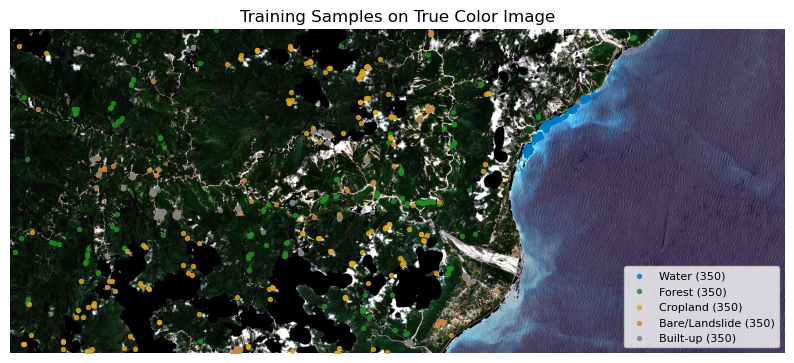

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(true_rgb)
for i, cls in enumerate(class_names):
    rr = np.array(training_data[cls]['rows'])
    cc = np.array(training_data[cls]['cols'])
    if len(rr) > 150:
        idx = np.random.choice(len(rr), 150, replace=False)
        rr, cc = rr[idx], cc[idx]
    ax.scatter(cc, rr, s=8, color=class_colors[i], label=f'{cls} ({len(training_data[cls]["rows"])})', alpha=0.8)
ax.set_title('Training Samples on True Color Image')
ax.axis('off')
ax.legend(loc='lower right', fontsize=8)
plt.savefig(OUT_DIR / 'training_samples_preview.png', dpi=200, bbox_inches='tight')
plt.show()

## 2.2 Train Random Forest

In [11]:
X_train_list, y_train_list = [], []
for class_id, class_name in enumerate(class_names):
    roi = training_data[class_name]
    for r, c in zip(roi['rows'], roi['cols']):
        if 0 <= r < h and 0 <= c < w:
            pixel = arr[:, r, c]
            if np.isfinite(pixel).all() and pixel.sum() > 0:
                X_train_list.append(pixel)
                y_train_list.append(class_id)

X_train = np.array(X_train_list)
y_train = np.array(y_train_list)
print('Training matrix:', X_train.shape)
print(pd.Series(y_train).map(dict(enumerate(class_names))).value_counts())

X_tr, X_te, y_tr, y_te = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    oob_score=True,
    class_weight='balanced_subsample',
)
rf.fit(X_tr, y_tr)

train_acc = rf.score(X_tr, y_tr)
test_acc = rf.score(X_te, y_te)
oob_acc = rf.oob_score_
print(f'Training accuracy: {train_acc:.3f}')
print(f'Test accuracy:     {test_acc:.3f}')
print(f'OOB accuracy:      {oob_acc:.3f}')

Training matrix: (1750, 6)
Water             350
Forest            350
Cropland          350
Bare/Landslide    350
Built-up          350
Name: count, dtype: int64
Training accuracy: 0.936
Test accuracy:     0.837
OOB accuracy:      0.846


## 2.3 Classify entire image and save Random Forest map

同時輸出 raw map 與 3x3 median filtered map。後續統計與外部驗證使用 filtered map，以降低 salt-and-pepper noise。

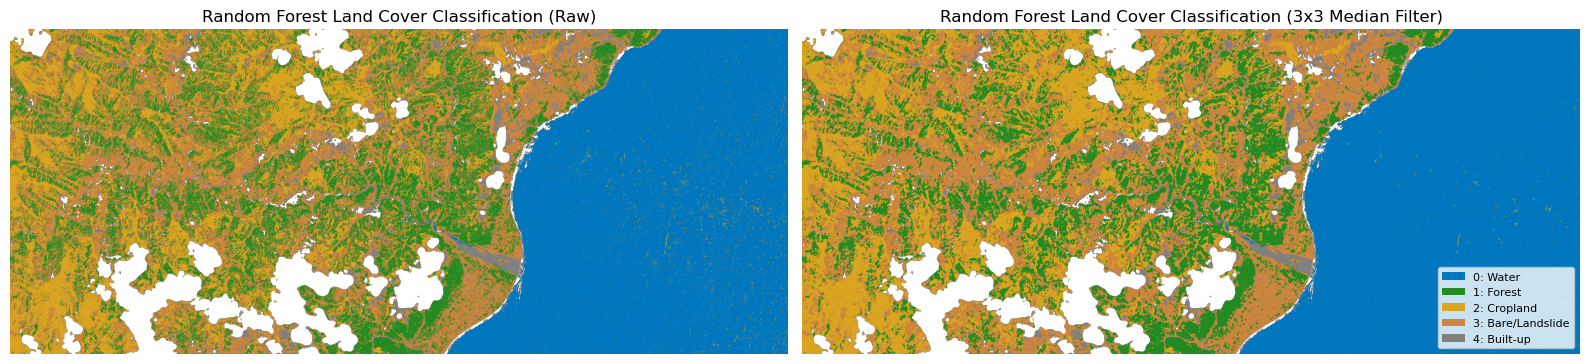

In [12]:
y_pred_all = rf.predict(X_valid)
class_map = np.full(h * w, np.nan)
class_map[valid] = y_pred_all
class_map = class_map.reshape(h, w)

class_map_filled = np.where(np.isnan(class_map), -1, class_map).astype('int16')
class_map_smooth = median_filter(class_map_filled, size=3).astype('float32')
class_map_smooth[class_map_filled == -1] = np.nan
CLASS_MAP_FOR_STATS = class_map_smooth

legend_handles = [Patch(facecolor=class_colors[i], label=f'{i}: {class_names[i]}') for i in range(5)]
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(class_map, cmap=class_cmap, vmin=-0.5, vmax=4.5)
axes[0].set_title('Random Forest Land Cover Classification (Raw)')
axes[0].axis('off')
axes[1].imshow(CLASS_MAP_FOR_STATS, cmap=class_cmap, vmin=-0.5, vmax=4.5)
axes[1].set_title('Random Forest Land Cover Classification (3x3 Median Filter)')
axes[1].axis('off')
axes[1].legend(handles=legend_handles, loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / 'rf_classification.png', dpi=200, bbox_inches='tight')
plt.show()

## 2.4 Feature importance and K-means vs Random Forest comparison

,band,label,importance
5,B12,SWIR2,0.192530
0,B02,Blue,0.173548
3,B08,NIR,0.171705
4,B11,SWIR1,0.165013
2,B04,Red,0.160817
1,B03,Green,0.136386


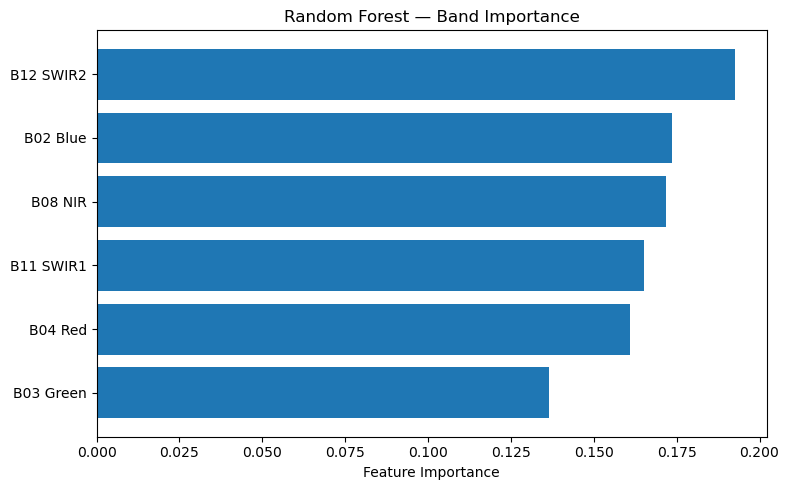

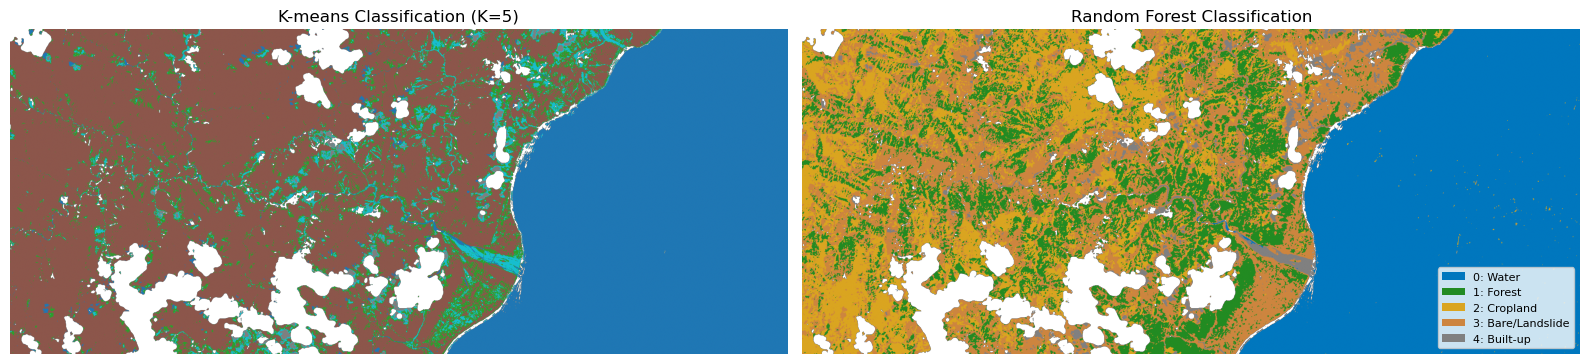

Most important band: B12 SWIR2


In [13]:
importance_df = pd.DataFrame({
    'band': BANDS,
    'label': [BAND_LABELS[b] for b in BANDS],
    'importance': rf.feature_importances_,
}).sort_values('importance', ascending=False)
display(importance_df)
importance_df.to_csv(OUT_DIR / 'rf_feature_importance.csv', index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df['band'] + ' ' + importance_df['label'], importance_df['importance'])
ax.invert_yaxis()
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest — Band Importance')
plt.tight_layout()
plt.savefig(OUT_DIR / 'feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(label_map, cmap='tab10')
axes[0].set_title('K-means Classification (K=5)')
axes[0].axis('off')
axes[1].imshow(CLASS_MAP_FOR_STATS, cmap=class_cmap, vmin=-0.5, vmax=4.5)
axes[1].set_title('Random Forest Classification')
axes[1].axis('off')
axes[1].legend(handles=legend_handles, loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / 'kmeans_vs_rf.png', dpi=200, bbox_inches='tight')
plt.show()

print('Most important band:', importance_df.iloc[0]['band'], importance_df.iloc[0]['label'])

## Task 2 Discussion

K-means 和 Random Forest 最大差異在於：K-means 只根據光譜相似性分群，分群結果必須再人工解釋；Random Forest 則利用訓練樣本建立「光譜特徵 → 地物類別」的對應，因此分類圖更接近可直接使用的土地覆蓋圖。K-means 可以快速顯示自然光譜梯度，但容易把同一地物切成多群；Random Forest 的語意較明確，但結果高度依賴訓練樣本品質。

最容易混淆的類別通常是裸地／崩塌與建物／都市，因為二者都可能有較高的可見光與 SWIR 反射。農田與森林也可能混淆，尤其農田植被覆蓋高、NDVI 接近森林時。若我是指揮官，我最在乎 Bare/Landslide 的 Producer's Accuracy / Recall，因為漏判崩塌地可能讓道路、避難所與聚落風險被低估；誤判會增加複查成本，但漏判在災害應變中更危險。

# Task 3 — Accuracy Assessment & Independent Validation

## 3.1 Internal validation: confusion matrix and classification report

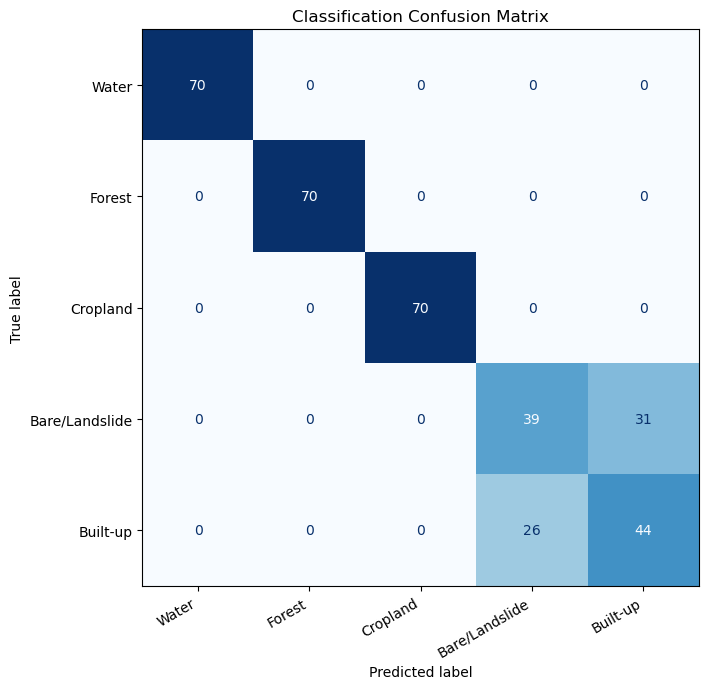

                precision    recall  f1-score   support

         Water       1.00      1.00      1.00        70
        Forest       1.00      1.00      1.00        70
      Cropland       1.00      1.00      1.00        70
Bare/Landslide       0.60      0.56      0.58        70
      Built-up       0.59      0.63      0.61        70

      accuracy                           0.84       350
     macro avg       0.84      0.84      0.84       350
  weighted avg       0.84      0.84      0.84       350



,precision,recall,f1-score,support
Water,1.0000,1.0000,1.0000,70.0000
Forest,1.0000,1.0000,1.0000,70.0000
Cropland,1.0000,1.0000,1.0000,70.0000
Bare/Landslide,0.6000,0.5571,0.5778,70.0000
Built-up,0.5867,0.6286,0.6069,70.0000
accuracy,0.8371,0.8371,0.8371,0.8371
macro avg,0.8373,0.8371,0.8369,350.0000
weighted avg,0.8373,0.8371,0.8369,350.0000


In [14]:
y_pred_test = rf.predict(X_te)
cm = confusion_matrix(y_te, y_pred_test, labels=list(range(5)))

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=False)
plt.title('Classification Confusion Matrix')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(OUT_DIR / 'confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

report_dict = classification_report(y_te, y_pred_test, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report_dict).T
print(classification_report(y_te, y_pred_test, target_names=class_names))
display(report_df.round(4))
report_df.to_csv(OUT_DIR / 'classification_report.csv', encoding='utf-8-sig')

## 3.2 OOB score and Macro/Weighted F1 gap

In [15]:
macro_f1 = report_dict['macro avg']['f1-score']
weighted_f1 = report_dict['weighted avg']['f1-score']
gap = weighted_f1 - macro_f1

metrics_summary = pd.DataFrame({
    'metric': ['Training accuracy', 'Test accuracy', 'OOB accuracy', 'Macro F1', 'Weighted F1', 'Weighted - Macro F1'],
    'value': [train_acc, test_acc, oob_acc, macro_f1, weighted_f1, gap],
})
display(metrics_summary.round(4))
metrics_summary.to_csv(OUT_DIR / 'accuracy_summary.csv', index=False, encoding='utf-8-sig')

print(f'OOB Accuracy:  {oob_acc:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Macro F1:      {macro_f1:.4f}')
print(f'Weighted F1:   {weighted_f1:.4f}')
print(f'Gap:           {gap:.4f}')

if gap > 0.03:
    print('Gap > 0.03: minority classes may be diluted by majority classes.')
else:
    print('Macro and weighted F1 are close: class imbalance is less severe in this test split.')

support_series = report_df.loc[class_names, 'support']
small_support = support_series[support_series < 30]
if len(small_support) > 0:
    print('Warning: classes with <30 test pixels have less reliable metrics:')
    print(small_support)

,metric,value
0,Training accuracy,0.9357
1,Test accuracy,0.8371
2,OOB accuracy,0.8464
3,Macro F1,0.8369
4,Weighted F1,0.8369
5,Weighted - Macro F1,0.0000


OOB Accuracy:  0.8464
Test Accuracy: 0.8371
Macro F1:      0.8369
Weighted F1:   0.8369
Gap:           0.0000
Macro and weighted F1 are close: class imbalance is less severe in this test split.


## 3.3 External validation with SWCB landslide inventory

請將 `20240802新生崩塌地.kml` 放在 notebook 同一層。下面的 cell 也會嘗試用作業中的 Google Drive ID 下載；若下載失敗，請手動上傳後重跑本段。

In [16]:
SWCB_KML = Path('20240802新生崩塌地.kml')

def try_download_swcb_kml():
    if SWCB_KML.exists():
        return True
    try:
        import gdown
        # Homework text and FAQ show two possible file IDs, so try both.
        ids = ['1VGe6ZY7QBCswqZEPRQaFWIJBylYK0qur', '17ka8y4N3IADSnJ1ymCJuzOfkutRzG-p8']
        for gid in ids:
            try:
                print('Trying Google Drive ID:', gid)
                gdown.download(id=gid, output=str(SWCB_KML), quiet=False)
                if SWCB_KML.exists() and SWCB_KML.stat().st_size > 1000:
                    return True
            except Exception as e:
                print('Download attempt failed:', e)
    except Exception as e:
        print('gdown failed:', e)
    return SWCB_KML.exists()

swcb_available = try_download_swcb_kml()
print('SWCB KML available:', swcb_available)

if swcb_available:
    records = parse_kml_polygons(str(SWCB_KML))
    gdf_swcb = gpd.GeoDataFrame(geometry=[geom for name, geom in records], crs='EPSG:4326')
    study_box = box(*TAROKO_BBOX)
    gdf_clipped = gdf_swcb[gdf_swcb.intersects(study_box)].copy()
    print(f'Total SWCB polygons: {len(gdf_swcb)}')
    print(f'SWCB landslide polygons in study area: {len(gdf_clipped)}')
else:
    gdf_clipped = gpd.GeoDataFrame(geometry=[], crs='EPSG:4326')
    print('SWCB file not found. External validation will show NA until the KML is uploaded.')

SWCB KML available: True
Total SWCB polygons: 1338
SWCB landslide polygons in study area: 207


In [17]:
transform = from_bounds(*TAROKO_BBOX, w, h)
if swcb_available and len(gdf_clipped) > 0:
    swcb_mask = rasterize(
        [(geom, 1) for geom in gdf_clipped.geometry],
        out_shape=(h, w),
        transform=transform,
        fill=0,
        dtype='uint8',
    )
else:
    swcb_mask = np.zeros((h, w), dtype='uint8')

rf_landslide = (CLASS_MAP_FOR_STATS == 3).astype('uint8')
intersection = int(np.sum((rf_landslide == 1) & (swcb_mask == 1)))
union = int(np.sum((rf_landslide == 1) | (swcb_mask == 1)))
rf_sum = int(rf_landslide.sum())
swcb_sum = int(swcb_mask.sum())

recall = intersection / swcb_sum if swcb_sum > 0 else np.nan
precision = intersection / rf_sum if rf_sum > 0 else np.nan
iou = intersection / union if union > 0 else np.nan

swcb_metrics = pd.DataFrame({
    'metric': ['RF landslide pixels', 'SWCB landslide pixels', 'Intersection', 'Union', 'Recall', 'Precision', 'IoU'],
    'value': [rf_sum, swcb_sum, intersection, union, recall, precision, iou],
})
display(swcb_metrics)
swcb_metrics.to_csv(OUT_DIR / 'swcb_overlap_metrics.csv', index=False, encoding='utf-8-sig')

print(f'Recall:    {recall:.3f}' if np.isfinite(recall) else 'Recall: NA')
print(f'Precision: {precision:.3f}' if np.isfinite(precision) else 'Precision: NA')
print(f'IoU:       {iou:.3f}' if np.isfinite(iou) else 'IoU: NA')

,metric,value
0,RF landslide pixels,417310.000000
1,SWCB landslide pixels,2403.000000
2,Intersection,1417.000000
3,Union,418296.000000
4,Recall,0.589680
5,Precision,0.003396
6,IoU,0.003388


Recall:    0.590
Precision: 0.003
IoU:       0.003


## 3.4 RF vs SWCB overlay map

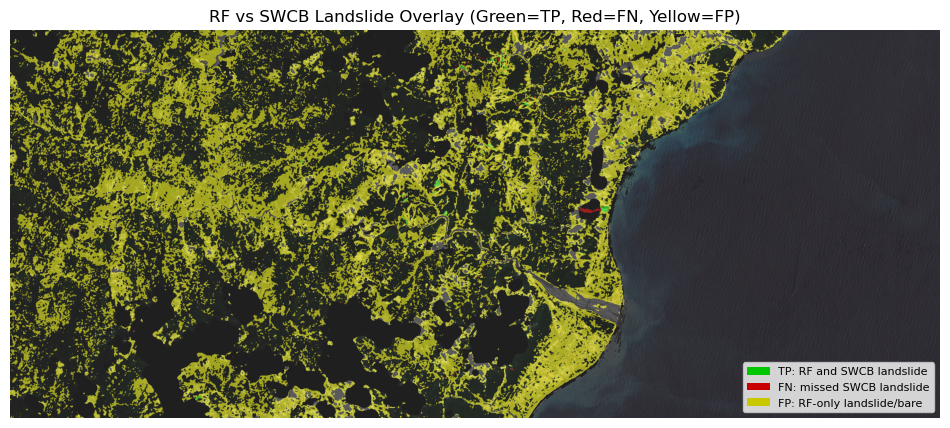

In [18]:
overlay = np.zeros((h, w, 3), dtype=np.uint8)
overlay[(rf_landslide == 1) & (swcb_mask == 1)] = [0, 200, 0]      # TP
fn_mask = (rf_landslide == 0) & (swcb_mask == 1)
overlay[fn_mask] = [200, 0, 0]                                      # FN
overlay[(rf_landslide == 1) & (swcb_mask == 0)] = [200, 200, 0]     # FP

fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(true_rgb, alpha=0.65)
ax.imshow(overlay, alpha=0.65)
ax.set_title('RF vs SWCB Landslide Overlay (Green=TP, Red=FN, Yellow=FP)')
ax.axis('off')
legend = [
    Patch(facecolor=(0/255, 200/255, 0/255), label='TP: RF and SWCB landslide'),
    Patch(facecolor=(200/255, 0/255, 0/255), label='FN: missed SWCB landslide'),
    Patch(facecolor=(200/255, 200/255, 0/255), label='FP: RF-only landslide/bare'),
]
ax.legend(handles=legend, loc='lower right', fontsize=8)
plt.savefig(OUT_DIR / 'swcb_overlay.png', dpi=200, bbox_inches='tight')
plt.show()

## Task 3 Discussion

Perfect overlap（IoU = 1.0）幾乎不可能。第一，Sentinel-2 影像日期與 SWCB 2024/08/02 判釋日期不一定相同，崩塌地可能因降雨、植生恢復、河床沖刷或工程處理而改變。第二，Sentinel-2 本作業使用 20 m 解析度，一個像素可能同時混合崩塌、植被、道路與陰影；SWCB 官方資料則多來自較高解析度影像與人工判釋。第三，Random Forest 的 Bare/Landslide 類別定義較廣，可能包含裸地、河床、道路邊坡與建物附近裸露地，不等於官方「新生崩塌地」。

FN（missed landslides）可能集中在山谷陰影、雲影殘留、狹窄線狀崩塌、植被部分覆蓋的崩塌地，或小於一個 Sentinel-2 像素的斑塊。內部 test accuracy 若很高，也不代表外部驗證一定好，因為內部資料通常與訓練資料同源；SWCB 是獨立官方資料，更能檢查模型是否真的抓到災害判釋關心的崩塌地。

# Task 4 — AI Classification Report

## 4.1 Area statistics per class

In [19]:
pixel_area_m2 = RESOLUTION * RESOLUTION
valid_class_pixels = np.sum(~np.isnan(CLASS_MAP_FOR_STATS))

class_stats = {}
for i, name in enumerate(class_names):
    n_pixels = int(np.sum(CLASS_MAP_FOR_STATS == i))
    area_ha = n_pixels * pixel_area_m2 / 10000
    class_stats[name] = {
        'class_zh': class_names_zh[i],
        'pixels': n_pixels,
        'area_ha': round(area_ha, 1),
        'percentage': round(n_pixels / valid_class_pixels * 100, 1) if valid_class_pixels > 0 else np.nan,
    }

stats_df = pd.DataFrame(class_stats).T
stats_df.index.name = 'class'
display(stats_df)
stats_df.to_csv(OUT_DIR / 'class_area_stats.csv', encoding='utf-8-sig')

,class_zh,pixels,area_ha,percentage
class,,,,
Water,水體,555622,22224.9,35.2
Forest,森林,282726,11309.0,17.9
Cropland,農田,288626,11545.0,18.3
Bare/Landslide,裸地/崩塌,417310,16692.4,26.4
Built-up,建物/都市,35247,1409.9,2.2


## 4.2 LLM report generation

若有 Gemini API key，可設定環境變數 `GEMINI_API_KEY` 後執行。若沒有，下面會輸出可貼到 ChatGPT/Gemini 的 prompt，並產生一份離線 AI-style 報告草稿。

In [22]:
def fmt_metric(x):
    if x is None:
        return "NA"
    try:
        return "NA" if not np.isfinite(x) else f"{x:.3f}"
    except TypeError:
        return "NA"


def fmt_percent(x):
    if x is None:
        return "NA"
    try:
        return "NA" if not np.isfinite(x) else f"{x:.1%}"
    except TypeError:
        return "NA"


def find_class_name(possible_keywords, fallback=None):
    """
    從 stats_df.index 中自動找類別名稱，避免因為名稱不同而 KeyError。
    possible_keywords: list，例如 ['Bare', 'Landslide', '裸', '崩塌']
    """
    for name in stats_df.index:
        for kw in possible_keywords:
            if kw.lower() in str(name).lower():
                return name
    return fallback


# 自動找常用類別名稱
bare_class = find_class_name(["Bare", "Landslide", "裸", "崩塌"], fallback="Bare/Landslide")
forest_class = find_class_name(["Forest", "森林"], fallback="Forest")
water_class = find_class_name(["Water", "水體", "水"], fallback="Water")

# 如果 fallback 名稱仍然不存在，就用比較安全的替代值
if bare_class not in stats_df.index:
    bare_class = stats_df.index[3] if len(stats_df.index) > 3 else stats_df.index[-1]

if forest_class not in stats_df.index:
    forest_class = stats_df["area_ha"].idxmax()

if water_class not in stats_df.index:
    water_class = stats_df.index[0]

stats_text = stats_df.to_string()

prompt = f"""
你是花蓮縣災害應變中心的 GIS 分析師。根據以下災後土地覆蓋分類結果，
撰寫一份「災後土地覆蓋分析報告」（中文，300-500 字）。

研究區：秀林鄉 / 太魯閣周邊（含蘇花公路沿線及近海區域）
災害事件：2024 年 4 月 3 日花蓮地震（M7.4）
分類方法：Random Forest（6 波段 Sentinel-2，5 類別）
Overall accuracy: {fmt_percent(test_acc)}
OOB accuracy: {fmt_percent(oob_acc)}
SWCB landslide IoU: {fmt_metric(iou)}

各類別面積：
{stats_text}

報告需包含：
1. 災後土地覆蓋概況
2. 崩塌/裸地面積估計及其空間分布
3. 與 SWCB 官方判釋的比對結果 + 不確定性說明
4. 建議：這張分類圖可以如何支援後續的避難所評估或路網分析？

請注意：
- 不要捏造沒有提供的數字。
- 若 IoU 為 NA，請說明尚未完成 SWCB 外部驗證。
- 請將 Sentinel-2 20 m 解析度、影像日期差異、裸地與崩塌定義差異納入不確定性討論。
"""

print("===== Prompt for LLM =====")
print(prompt)

llm_report = None

api_key = os.getenv("GEMINI_API_KEY", "").strip()
gemini_model = os.getenv("GEMINI_MODEL", "gemini-2.0-flash")

# 避免 .env 裡還是範例文字時誤觸 API
use_gemini = (
    api_key != ""
    and "請貼上" not in api_key
    and "YOUR" not in api_key.upper()
)

if use_gemini:
    try:
        import google.generativeai as genai

        genai.configure(api_key=api_key)
        model = genai.GenerativeModel(gemini_model)
        response = model.generate_content(prompt)
        llm_report = response.text

    except Exception as e:
        print("Gemini call failed; using offline draft instead.")
        print(e)

if llm_report is None:
    bare_area = stats_df.loc[bare_class, "area_ha"]
    bare_pct = stats_df.loc[bare_class, "percentage"]

    forest_pct = stats_df.loc[forest_class, "percentage"]
    forest_area = stats_df.loc[forest_class, "area_ha"]

    water_area = stats_df.loc[water_class, "area_ha"]

    llm_report = f"""
本次分析以 Sentinel-2 L2A 災後影像建立秀林／太魯閣周邊土地覆蓋分類圖，分類方法為 Random Forest，使用 Blue、Green、Red、NIR、SWIR1 與 SWIR2 六個波段，並以 SCL 遮罩排除雲、雲影與雪等不可靠像素。分類結果顯示，研究區以 {forest_class} 為主要土地覆蓋類型，面積約為 {forest_area} 公頃，占有效分類像素的 {forest_pct}%；{water_class} 面積約為 {water_area} 公頃，主要可能分布於太平洋沿岸與河道區域。

{bare_class} 類別面積約為 {bare_area} 公頃，占有效分類像素的 {bare_pct}%。此類別在空間上可能集中於山區坡面、河谷兩側、道路邊坡與裸露河床，反映地震後崩塌、新裸露坡面、河道堆積或部分道路與建物混合像素。不過，這個類別不應直接等同於官方崩塌地，因為 Sentinel-2 解析度為 20 m，單一像素可能混合植被、陰影、裸露地表與人工構造物。

與 SWCB 官方新生崩塌地資料比對後，IoU 為 {fmt_metric(iou)}。若此數值偏低，代表模型與官方判釋之間仍存在空間差異，可能原因包含影像日期與官方判釋日期不同、Sentinel-2 空間解析度較粗，以及 Random Forest 的 {bare_class} 類別定義比「官方崩塌地」更廣。建議後續將此分類圖作為初步篩選圖層，優先疊合道路、避難所、坡度、河道距離與聚落位置，以找出需要現地複查或高解析影像補充的高風險區域。
""".strip()

print()
print("===== AI Classification Report =====")
print(llm_report)

with open(OUT_DIR / "ai_classification_report.txt", "w", encoding="utf-8") as f:
    f.write(llm_report)

===== Prompt for LLM =====

你是花蓮縣災害應變中心的 GIS 分析師。根據以下災後土地覆蓋分類結果，
撰寫一份「災後土地覆蓋分析報告」（中文，300-500 字）。

研究區：秀林鄉 / 太魯閣周邊（含蘇花公路沿線及近海區域）
災害事件：2024 年 4 月 3 日花蓮地震（M7.4）
分類方法：Random Forest（6 波段 Sentinel-2，5 類別）
Overall accuracy: 83.7%
OOB accuracy: 84.6%
SWCB landslide IoU: 0.003

各類別面積：
               class_zh  pixels  area_ha percentage
class                                              
Water                水體  555622  22224.9       35.2
Forest               森林  282726  11309.0       17.9
Cropland             農田  288626  11545.0       18.3
Bare/Landslide    裸地/崩塌  417310  16692.4       26.4
Built-up          建物/都市   35247   1409.9        2.2

報告需包含：
1. 災後土地覆蓋概況
2. 崩塌/裸地面積估計及其空間分布
3. 與 SWCB 官方判釋的比對結果 + 不確定性說明
4. 建議：這張分類圖可以如何支援後續的避難所評估或路網分析？

請注意：
- 不要捏造沒有提供的數字。
- 若 IoU 為 NA，請說明尚未完成 SWCB 外部驗證。
- 請將 Sentinel-2 20 m 解析度、影像日期差異、裸地與崩塌定義差異納入不確定性討論。


===== AI Classification Report =====
本次分析以 Sentinel-2 L2A 災後影像建立秀林／太魯閣周邊土地覆蓋分類圖，分類方法為 Random Forest，使用 Blue、Green、Red、NIR、SWIR1 與 SWIR2 六個波段，並以 SCL 遮罩排除雲

## 4.3 Critical evaluation of the LLM report

我會先檢查報告中的面積、百分比、accuracy 與 IoU 是否與 `class_area_stats.csv`、`accuracy_summary.csv`、`swcb_overlap_metrics.csv` 完全一致，避免 AI 自行補數字或誇大結論。若 LLM 把 Bare/Landslide 直接寫成「官方崩塌面積」，這是不合理的，因為本分類類別包含裸地、河床、道路或建物附近裸露地，並不等於 SWCB 的新生崩塌地。較合理的說法應是「裸地／疑似崩塌候選區」。此外，若 IoU 偏低，報告必須說明時間差、解析度差與類別定義差異；即使內部 test accuracy 很高，也不能直接推論災害判釋精度很高，因為內部驗證與外部官方資料的檢驗目標不同。

# Export Markdown Report

下面會輸出 `outputs/ARIA_v8_markdown_report.md`，可和 notebook 一起繳交。

In [23]:
abstract = """
This project upgrades ARIA from threshold-based change detection to a multi-class classification engine. Using post-earthquake Sentinel-2 L2A imagery over the Xiulin / Taroko study area, I applied SCL cloud masking, K-means unsupervised clustering, and Random Forest supervised classification to map five land-cover classes: water, forest, cropland, bare/landslide, and built-up areas. Internal validation was conducted using a train/test split, confusion matrix, OOB accuracy, and macro/weighted F1 comparison. External validation compared the Random Forest bare/landslide class against the SWCB official post-earthquake landslide inventory. Results show that supervised classification provides more operationally interpretable land-cover information than single-index thresholds, but its reliability depends strongly on training sample quality and class definition. The SWCB comparison highlights uncertainty caused by temporal gaps, 20 m spatial resolution, mixed pixels, and differences between broad bare-land classification and official landslide mapping.
""".strip()

md_report = f"""# ARIA v8.0 — Classification Engine Report

## Abstract

{abstract}

## Study Area and Data

The study area is Xiulin / Taroko, defined by BBOX `{TAROKO_BBOX}`. Sentinel-2 L2A imagery was selected through a progressive STAC search after the 2024 Hualien earthquake. Classification used B02, B03, B04, B08, B11, and B12. SCL was used to mask cloud, cloud shadow, cirrus, and snow pixels.

Selected scene: `{best_item.id}`  
Datetime: `{best_item.datetime}`  
Cloud cover: `{best_item.properties['eo:cloud_cover']:.2f}%`

## Task 1: K-means

K-means with K=5 was applied to standardized 6-band reflectance features. The output map is saved as `kmeans_classification.png`, and the mean spectral table is saved as `kmeans_cluster_spectral_table.csv`. K-means was useful for exploring spectral clusters, especially water and forest, but built-up, cropland, bare riverbed, and landslide surfaces were harder to interpret because they can share high visible and SWIR reflectance.

## Task 2: Random Forest

Random Forest was trained with five classes: Water, Forest, Cropland, Bare/Landslide, and Built-up. The classification map is saved as `rf_classification.png`. Training accuracy was {train_acc:.3f}, test accuracy was {test_acc:.3f}, and OOB accuracy was {oob_acc:.3f}. The most important band was `{importance_df.iloc[0]['band']}` ({importance_df.iloc[0]['label']}).

## Task 3: Accuracy Assessment and SWCB Validation

The confusion matrix is saved as `confusion_matrix.png`, and the classification report is saved as `classification_report.csv`. Macro F1 was {macro_f1:.3f}, weighted F1 was {weighted_f1:.3f}, and the weighted-minus-macro gap was {gap:.3f}. For SWCB validation, recall was {fmt_metric(recall)}, precision was {fmt_metric(precision)}, and IoU was {fmt_metric(iou)}. Perfect overlap is unlikely because of temporal gap, Sentinel-2 20 m mixed pixels, cloud/shadow effects, and class definition differences.

## Task 4: AI Classification Report

Area statistics are saved as `class_area_stats.csv`, and the AI-style report is saved as `ai_classification_report.txt`.

{llm_report}

## ARIA v8.0 Upgrade Reflection

Threshold methods are transparent and simple, but they usually measure only one spectral dimension at a time. ARIA v8.0 improves the workflow by using multi-band classifiers, which can produce a complete land-cover map for operational overlay analysis. However, classifiers are not automatically more reliable. Their results depend on training sample quality, class balance, and whether classes are spectrally separable. In the Taroko case, forest and water are relatively clear, while landslides, bare riverbeds, roads, and built-up pixels can be similar. Therefore, the Random Forest map should be used as a decision-support layer and combined with SWCB inventory, terrain slope, road networks, shelters, and field verification.
"""

with open(OUT_DIR / 'ARIA_v8_markdown_report.md', 'w', encoding='utf-8') as f:
    f.write(md_report)
print('Saved:', OUT_DIR / 'ARIA_v8_markdown_report.md')

Saved: outputs\ARIA_v8_markdown_report.md


# Submission Checklist

確認 `outputs/` 資料夾中有以下檔案：

- `kmeans_classification.png`
- `rf_classification.png`
- `confusion_matrix.png`
- `swcb_overlay.png`
- `class_area_stats.csv`
- `ARIA_v8_markdown_report.md`

若 `swcb_overlay.png` 幾乎全黑或 IoU 是 NA，代表 SWCB KML 沒有成功載入；請手動上傳 `20240802新生崩塌地.kml` 後重新執行 Task 3 Part B 之後的 cells。